# TransFit Tutorial: Fitting the Example Data

This notebook fits the two example data files shipped with TransFit:

- `sn1993j_lbol.txt`: bolometric luminosity data.
- `sn2007gr.csv`: multi-band `B/V/R/I` photometry.

Both examples use the `nickel` model and run `emcee` with `nsteps=5000`.

In [1]:
from pathlib import Path
import sys

# Make the notebook work both from the repository root and from examples/.
CWD = Path.cwd().resolve()
if (CWD / "transfit").is_dir():
    REPO_ROOT = CWD
elif (CWD.parent / "transfit").is_dir():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError("Could not locate the local TransFit repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import transfit as tf

DATA_DIR = REPO_ROOT / "examples" / "data"
OUT_DIR = REPO_ROOT / "mcmc_out"
OUT_DIR.mkdir(exist_ok=True)
print("Using TransFit from:", Path(tf.__file__).resolve())

Using TransFit from: C:\Users\zyh\Desktop\TransFit\transfit\__init__.py


## 1. Load the example data

In [2]:
def load_sn1993j_bolometric():
    arr = np.loadtxt(DATA_DIR / "sn1993j_lbol.txt", comments="#")
    t_days = arr[:, 0] - np.nanmin(arr[:, 0])
    return tf.BolometricData(
        t_days=t_days,
        y=arr[:, 1],
        yerr=arr[:, 2],
    )


def load_sn2007gr_multiband():
    df = pd.read_csv(DATA_DIR / "sn2007gr.csv")
    phase = np.asarray(df["Phase"], float)
    t0 = float(np.nanmin(phase))

    mag_cols = {
        "B": ("Bmag", "e_Bmag"),
        "V": ("Vmag", "e_Vmag"),
        "R": ("Rmag", "e_Rmag"),
        "I": ("Imag", "e_Imag"),
    }

    t_days, bands, y, yerr = [], [], [], []
    for band, (mcol, ecol) in mag_cols.items():
        mag = pd.to_numeric(df[mcol], errors="coerce").to_numpy(float)
        err = pd.to_numeric(df[ecol], errors="coerce").to_numpy(float)
        good = np.isfinite(phase) & np.isfinite(mag) & np.isfinite(err) & (err > 0.0)
        t_days.extend((phase[good] - t0).tolist())
        y.extend(mag[good].tolist())
        yerr.extend(err[good].tolist())
        bands.extend([band] * int(np.sum(good)))

    order = np.argsort(np.asarray(t_days, float))
    return tf.MultiBandData(
        t_days=np.asarray(t_days, float)[order],
        band=np.asarray(bands, dtype=object)[order],
        y=np.asarray(y, float)[order],
        yerr=np.asarray(yerr, float)[order],
    )


bol_data = load_sn1993j_bolometric()
mb_data = load_sn2007gr_multiband()

print(f"SN1993J bolometric points: {bol_data.t_days.size}")
print(f"SN2007gr multiband points: {mb_data.t_days.size}, bands: {mb_data.bands}")

SN1993J bolometric points: 89
SN2007gr multiband points: 307, bands: ['B', 'I', 'R', 'V']


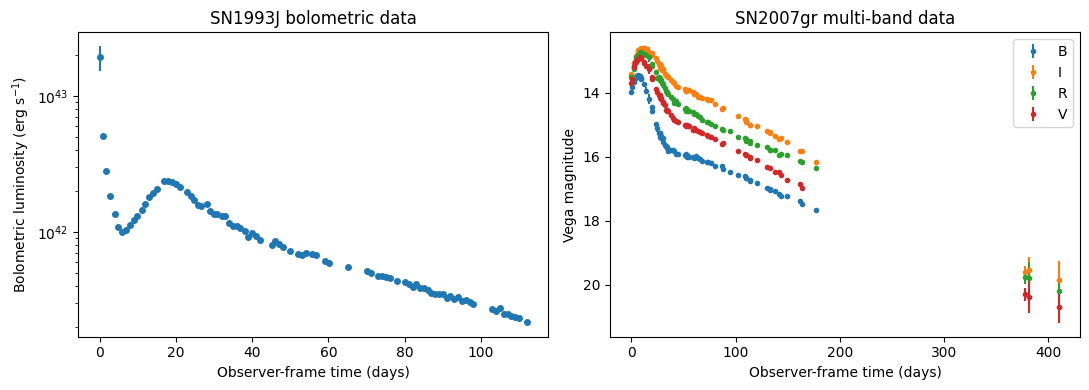

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].errorbar(bol_data.t_days, bol_data.y, yerr=bol_data.yerr, fmt="o", ms=4)
axes[0].set_yscale("log")
axes[0].set_xlabel("Observer-frame time (days)")
axes[0].set_ylabel("Bolometric luminosity (erg s$^{-1}$)")
axes[0].set_title("SN1993J bolometric data")

for band in mb_data.bands:
    m = mb_data.band == band
    axes[1].errorbar(mb_data.t_days[m], mb_data.y[m], yerr=mb_data.yerr[m], fmt=".", ms=6, label=band)
axes[1].invert_yaxis()
axes[1].set_xlabel("Observer-frame time (days)")
axes[1].set_ylabel("Vega magnitude")
axes[1].set_title("SN2007gr multi-band data")
axes[1].legend()

fig.tight_layout()

## 2. Shared model and sampler settings

In [4]:
print(tf.model_param_names("nickel"))

EMCEE_5000 = {
    "nwalkers": 32,
    "nsteps": 5000,
    "burnin": 1000,
    "thin": 10,
    "seed": 123,
    "progress": False,
    "robust_init": False,
}

nickel_priors = {
    "M_ej": (0.5, 8.0),
    "v_ej": (0.2, 3.0),
    "E_Th_in": (0.05, 8.0),
    "M_ni": ("log10", -3.0, -0.2),
    "R_0": (10.0, 400.0),
    "t_shift": (0.0, 20.0),
}

fixed_bol = {
    "f_ni": 0.2,
    "kappa": 0.12,
    "kappa_gamma": 0.03,
}

fixed_multiband = {
    "f_ni": 0.2,
    "kappa": 0.12,
    "kappa_gamma": 0.03,
    "T_floor": 4500.0,
}

filters = {
    "B": "johnson_cousins.B",
    "V": "johnson_cousins.V",
    "R": "johnson_cousins.R",
    "I": "johnson_cousins.I",
}

['M_ej', 'v_ej', 'E_Th_in', 'M_ni', 'R_0', 'f_ni', 'kappa', 'kappa_gamma', 'T_floor']


## 3. Fit `sn1993j_lbol.txt` with `emcee`

In [5]:
res_bol = tf.fit_bol(
    data=bol_data,
    model="nickel",
    z=0.001728,
    priors=nickel_priors,
    fixed=fixed_bol,
    sampler="emcee",
    sampler_kwargs=EMCEE_5000,
)

print("Bolometric fit samples:", res_bol.samples.shape)
print("Bolometric best log_prob:", res_bol.best_log_prob)
res_bol.best_params_raw

Bolometric fit samples: (16000, 6)
Bolometric best log_prob: -4594.354627847553


{'M_ej': 0.714449754801301,
 'v_ej': 0.42653829257584713,
 'E_Th_in': 2.3698358106867268,
 'M_ni': 0.0993955486380158,
 'R_0': 399.89211569189956,
 'f_ni': 0.2,
 'kappa': 0.12,
 'kappa_gamma': 0.03,
 't_shift': 1.3294379627300497}

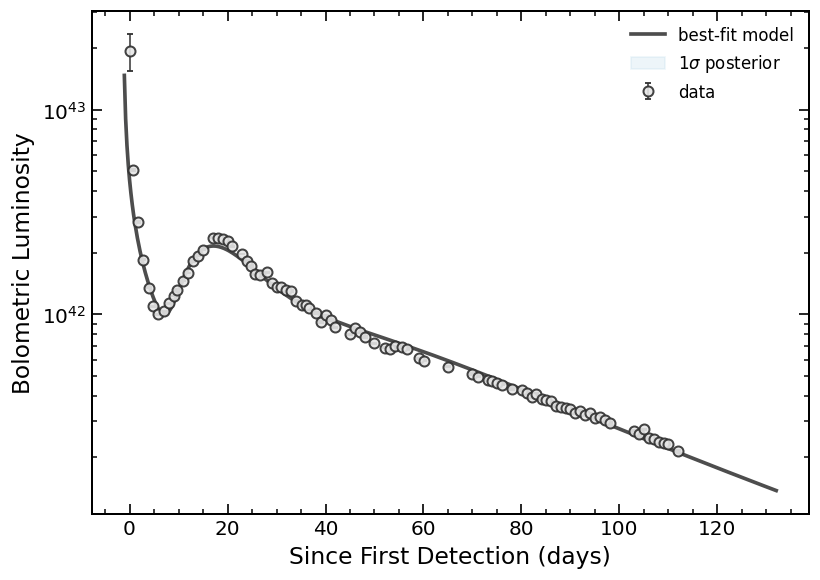

In [6]:
fig_bol = tf.plot.fit_bol(
    res_bol,
    data=bol_data,
    show_1sigma=True,
    n_draws=100,
    n_t=500,
    t_pad=20.0,
)
fig_bol

## 4. Fit `sn2007gr.csv` with `emcee`

In [7]:
res_mb = tf.fit_multiband(
    data=mb_data,
    model="nickel",
    z=0.001728,
    filters=filters,
    y_kind="mag",
    mag_system="vega",
    priors=nickel_priors,
    fixed=fixed_multiband,
    sampler="emcee",
    sampler_kwargs={**EMCEE_5000, "seed": 456},
)

print("Multi-band fit samples:", res_mb.samples.shape)
print("Multi-band best log_prob:", res_mb.best_log_prob)
res_mb.best_params_raw

Multi-band fit samples: (16000, 6)
Multi-band best log_prob: -4564.767169043679


{'M_ej': 0.994118172772518,
 'v_ej': 0.3148384376311777,
 'E_Th_in': 4.613445134496365,
 'M_ni': 0.03406747578142518,
 'R_0': 399.92763639008064,
 'f_ni': 0.2,
 'kappa': 0.12,
 'kappa_gamma': 0.03,
 'T_floor': 4500.0,
 't_shift': 8.08210076649189}

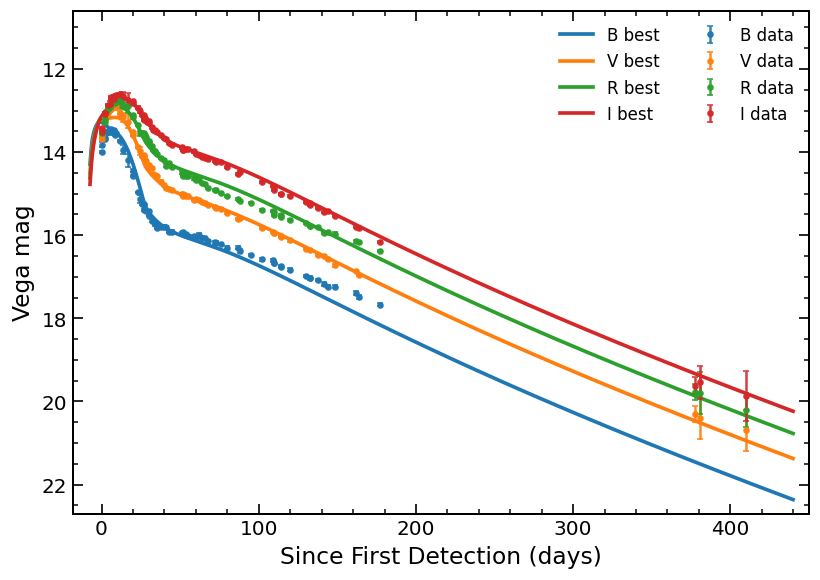

In [8]:
fig_mb = tf.plot.fit_multiband(
    res_mb,
    data=mb_data,
    show_1sigma=False,
    n_t=600,
    t_pad=30.0,
)
fig_mb

## 5. Save the results

In [9]:
bol_path = tf.save(res_bol, OUT_DIR / "tutorial_sn1993j_bol_emcee5000.npz")
mb_path = tf.save(res_mb, OUT_DIR / "tutorial_sn2007gr_multiband_emcee5000.npz")

print("Saved bolometric result:", bol_path)
print("Saved multi-band result:", mb_path)
print("Loaded bolometric samples:", tf.load(bol_path)["samples"].shape)
print("Loaded multi-band samples:", tf.load(mb_path)["samples"].shape)

Saved bolometric result: C:\Users\zyh\Desktop\TransFit\mcmc_out\tutorial_sn1993j_bol_emcee5000.npz
Saved multi-band result: C:\Users\zyh\Desktop\TransFit\mcmc_out\tutorial_sn2007gr_multiband_emcee5000.npz
Loaded bolometric samples: (16000, 6)
Loaded multi-band samples: (16000, 6)
